In [38]:
import pandas as pd
df = pd.read_csv("course_final.csv", encoding = "utf-8", index_col= 0)

In [39]:
df.info()

<class 'pandas.DataFrame'>
Index: 533993 entries, HarvardX/PH207x/2012_Fall to MITx/6.00x/2013_Spring
Data columns (total 30 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   userid_DI             533993 non-null  str    
 1   registered            533993 non-null  int64  
 2   viewed                533993 non-null  int64  
 3   explored              533993 non-null  int64  
 4   certified             533993 non-null  int64  
 5   final_cc_cname_DI     533993 non-null  str    
 6   LoE_DI                533993 non-null  str    
 7   YoB                   452939 non-null  float64
 8   gender                533993 non-null  str    
 9   grade                 491268 non-null  str    
 10  start_time_DI         533993 non-null  str    
 11  last_event_DI         533993 non-null  str    
 12  nevents               532186 non-null  float64
 13  ndays_act             532186 non-null  float64
 14  nplay_video           348922

In [40]:
missing_summary = pd.DataFrame({
    'missing_count' : df.isnull().sum(),
    'missing_ratio(%)' : (df.isnull().mean()*100).round(2)
}).sort_values(by='missing_ratio(%)', ascending=False)
missing_summary

,missing_count,missing_ratio(%)
nplay_video,185071,34.66
LoE_num,87859,16.45
age_cleaned,81706,15.30
age_raw,81054,15.18
YoB,81054,15.18
age_final,81054,15.18
age,81054,15.18
nchapters,58210,10.90
grade,42725,8.00
ndays_act,1807,0.34


In [41]:
df.head()

,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,grade,...,start_year,age_raw,age_missing_original,age_invalid,age_cleaned,age_final,age,age_group,exam_flag,LoE_num
course_id,,,,,,,,,,,,,,,,,,,,,
HarvardX/PH207x/2012_Fall,MHxPC130275857,1,1,1,0,United States,unknown,NaN,unknown,0,...,2012,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN
HarvardX/CB22x/2013_Spring,MHxPC130539455,1,1,0,0,France,unknown,NaN,unknown,0,...,2013,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN
HarvardX/CB22x/2013_Spring,MHxPC130088379,1,1,0,0,United States,unknown,NaN,unknown,0,...,2013,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN
HarvardX/ER22x/2013_Spring,MHxPC130088379,1,1,0,0,United States,unknown,NaN,unknown,0,...,2013,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN
HarvardX/ER22x/2013_Spring,MHxPC130198098,1,1,0,0,United States,unknown,NaN,unknown,0,...,2013,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN


In [42]:
# 각 단계별 총 인원 합계
n_reg = df['registered'].sum()
n_view = df['viewed'].sum()
n_exp = df['explored'].sum()

print(n_reg)
print(n_view)
print(n_exp)

533993
325361
37584


In [43]:
# 각 단계별 총 인원 합계
n_reg = df['registered'].sum()
n_view = df['viewed'].sum()
n_exp = df['explored'].sum()

# 등록자 중 실제 강의를 본 비율
reg_to_view = (n_view / n_reg) * 100
# 이탈률
drop_out_reg_to_view = 100 - reg_to_view

# 강의를 본 사람 중 탐색한 비율
view_to_exp = (n_exp / n_view) * 100
# 이탈률
drop_out_view_to_exp = 100 - view_to_exp

# 전체 등록자 대비 탐색 비율
total_conversion = (n_exp / n_reg) * 100

print(f"========== 단계별 참여 및 이탈 구조 ==========")
print(f"registered -> viewed 전환율 : {reg_to_view:.2f}%")
print(f"registered -> viewed 이탈률 : {drop_out_reg_to_view:.2f}%")
print()
print(f"viewed -> explored 전환율 : {view_to_exp:.2f}%")
print(f"viewed -> explored 이탈률 : {drop_out_view_to_exp:.2f}%")
print()
print(f"최종 explored 전환율 : {total_conversion:.2f}%")

========== 단계별 참여 및 이탈 구조 ==========
registered -> viewed 전환율 : 60.93%
registered -> viewed 이탈률 : 39.07%

viewed -> explored 전환율 : 11.55%
viewed -> explored 이탈률 : 88.45%

최종 explored 전환율 : 7.04%


In [44]:
import plotly.graph_objects as go

stages = ["Registered", "Viewed", "Explored"]
counts = [n_reg, n_view, n_exp]

fig = go.Figure(go.Funnel(
    y = stages,
    x = counts,
    textinfo = "value+percent initial+percent previous",
    marker = {"color": ["#636EFA", "#EF553B", "#00CC96"]}
))

fig.update_layout(title_text='학습 퍼널 및 단계별 전환율 진단')
fig.show() 

In [45]:
# 이탈자 유형 세분화

# Step 1. 진입 전 이탈
step1 = ((df['registered'] == 1) & (df['viewed'] == 0)).sum()

# Step 2-1. 진입 직후 이탈
step2_1 = ((df['viewed'] == 1) & (df['nevents'].isna()) & (df['explored'] == 0)).sum()

# Step 2-2. 탐색 시도 후 이탈
step2_2 = ((df['viewed'] == 1) & (df['nevents'] > 0) & (df['explored'] == 0)).sum()

print(f"진입 전 이탈 : {step1:,}명")
print(f"진입 직후 이탈 : {step2_1:,}명")
print(f"탐색 시도 후 이탈 : {step2_2:,}명")

진입 전 이탈 : 208,632명
진입 직후 이탈 : 1,807명
탐색 시도 후 이탈 : 285,970명


In [46]:
target_group = df[(df['viewed'] == 1) & (df['nevents'] > 0) & (df['explored'] == 0)]

# 확인할 지표 리스트
check_cols = ['nchapters', 'ndays_act', 'nplay_video']

print(f"===== [탐색 시도 후 이탈자] ({len(target_group):,}명) 대상 활동 지표 기록 현황 =====")

for col in check_cols:
    exists_count = target_group[col].notna().sum()
    exists_ratio = (exists_count / len(target_group)) * 100
    
    print(f"[{col}] 기록 존재 : {exists_count:,}명 ({exists_ratio:.2f}%)")
    print(f"[{col}] 결측(NaN) -> 도달 못함 : {len(target_group) - exists_count:,}명")
    print("-" * 50)

===== [탐색 시도 후 이탈자] (285,970명) 대상 활동 지표 기록 현황 =====
[nchapters] 기록 존재 : 270,004명 (94.42%)
[nchapters] 결측(NaN) -> 도달 못함 : 15,966명
--------------------------------------------------
[ndays_act] 기록 존재 : 285,970명 (100.00%)
[ndays_act] 결측(NaN) -> 도달 못함 : 0명
--------------------------------------------------
[nplay_video] 기록 존재 : 157,484명 (55.07%)
[nplay_video] 결측(NaN) -> 도달 못함 : 128,486명
--------------------------------------------------


In [47]:
# 탐색 시도 후 이탈자 행동 분석
avg_video_target = target_group['nplay_video'].mean()
print(f"탐색 시도 후 이탈자 평균 영상 재생 횟수 : {avg_video_target:.2f}회")

탐색 시도 후 이탈자 평균 영상 재생 횟수 : 50.52회


In [48]:
# explored 그룹 행동 분석
step3_total = df[df['explored'] == 1]
avg_video = step3_total['nplay_video'].mean()
print(f"explored 유저 평균 영상 재생 횟수 : {avg_video:.2f}회")

explored 유저 평균 영상 재생 횟수 : 550.49회


In [49]:
# explored 유형 활동 중심 세분화
step3_total = df[df['explored'] == 1]
step3_total_count = (df['explored'] == 1).sum()

# Step 3-1. 영상 몰입형 
step3_1 = (step3_total['nplay_video'] > avg_video).sum()

# Step 3-2 일반 달성자
step3_2 = (step3_total['nplay_video'] <= avg_video).sum()

print(f"=== Step 3. explored 집단 상세 분석 ===")
print(f"explored 유저 수 : {step3_total_count:,}명")
print(f"영상 몰입형: {step3_1:,}명")
print(f"일반 달성자: {step3_2:,}명")
print()
missing_count = step3_total['nplay_video'].isna().sum()
print(f"영상 기록이 없는(NaN) explored 유저 : {missing_count:,}명")

=== Step 3. explored 집단 상세 분석 ===
explored 유저 수 : 37,584명
영상 몰입형: 7,760명
일반 달성자: 16,015명

영상 기록이 없는(NaN) explored 유저 : 13,809명


In [50]:
from scipy import stats

# 1. explored 내 두 그룹 정의
success_group = df[df['explored'] == 1]
success_video_high = success_group[success_group['nplay_video'] > success_group['nplay_video'].mean()]
success_video_nan = success_group[success_group['nplay_video'].isna()]

# 2. 전체 이벤트(nevents) 평균 차이 검정
t_stat, p_val = stats.ttest_ind(success_video_high['nevents'], success_video_nan['nevents'], equal_var=False)

print(f"영상 몰입형 평균 이벤트 발생 횟수 : {success_video_high['nevents'].mean():.2f}회")
print(f"영상 기록이 없는 (NaN) 평균 이벤트 발생 횟수: {success_video_nan['nevents'].mean():.2f}회")
print(f"P-value: {p_val:.4e}")

if p_val < 0.05:
    print("\n결론: 두 집단의 활동 방식이 통계적으로 확연히 다름")
else:
    print("\n결론: 활동량 차이가 크지 않음 (다른 요인이 있을 수 있음)")

영상 몰입형 평균 이벤트 발생 횟수 : 8024.67회
영상 기록이 없는 (NaN) 평균 이벤트 발생 횟수: 617.94회
P-value: 0.0000e+00

결론: 두 집단의 활동 방식이 통계적으로 확연히 다름


In [51]:
import pandas as pd
from scipy.stats import chi2_contingency

# 1.  explored 내 두 그룹 준비
success_group = df[df['explored'] == 1].copy()
success_video_high = success_group[success_group['nplay_video'] > success_group['nplay_video'].mean()].copy()
success_video_nan = success_group[success_group['nplay_video'].isna()].copy()

# 2. 비교할 변수 리스트
vars_to_check = ['nforum_posts', 'exam_flag', 'nchapters']

for var in vars_to_check:
    # '기록 있음' 여부를 새로운 컬럼으로 생성 (NaN이면 0, 값이 있으면 1)
    success_video_high['has_record'] = success_video_high[var].notna().astype(int)
    success_video_nan['has_record'] = success_video_nan[var].notna().astype(int)
    
    # 교차표 생성
    high_counts = success_video_high['has_record'].value_counts()
    nan_counts = success_video_nan['has_record'].value_counts()
    
    # 통계 검정 (데이터가 양쪽 그룹에 모두 존재할 때만)
    contingency = pd.DataFrame([high_counts, nan_counts], index=['High_Effort', 'Video_NaN'])
    chi2, p, dof, expected = chi2_contingency(contingency.fillna(0))
    
    print(f"[{var}] 기록 보유 비율 차이 검정")
    print(f"- 영상 몰입형 기록 보유율: {success_video_high['has_record'].mean():.2%}")
    print(f"- 영상 기록이 없는 (NaN) 기록 보유율: {success_video_nan['has_record'].mean():.2%}")
    print(f"- P-value: {p:.4e}")
    print("-" * 30)

[nforum_posts] 기록 보유 비율 차이 검정
- 영상 몰입형 기록 보유율: 100.00%
- 영상 기록이 없는 (NaN) 기록 보유율: 100.00%
- P-value: 1.0000e+00
------------------------------
[exam_flag] 기록 보유 비율 차이 검정
- 영상 몰입형 기록 보유율: 100.00%
- 영상 기록이 없는 (NaN) 기록 보유율: 100.00%
- P-value: 1.0000e+00
------------------------------
[nchapters] 기록 보유 비율 차이 검정
- 영상 몰입형 기록 보유율: 100.00%
- 영상 기록이 없는 (NaN) 기록 보유율: 100.00%
- P-value: 1.0000e+00
------------------------------


In [52]:
# 1. 성공자(효율형) 데이터
low_effort_success = df[(df['explored'] == 1) & (df['nplay_video'].isna())]
# 2. 이탈자 데이터
target_group = df[(df['viewed'] == 1) & (df['nevents'] > 0) & (df['explored'] == 0)]

# 비교할 지표 리스트
metrics = ['ndays_act', 'duration', 'nchapters']

for m in metrics:
    success_mean = low_effort_success[m].mean()
    churn_mean = target_group[m].mean()
    
    # 이탈자 중 성공자 평균도 못 채우는 비율
    under_ratio = (target_group[m] < success_mean).mean() * 100
    
    print(f"[{m}] 기준")
    print(f"- 성공자 평균: {success_mean:.2f}")
    print(f"- 이탈자 평균: {churn_mean:.2f}")
    print(f"- 기준 미달 이탈자 비율: {under_ratio:.1f}%")
    print("-" * 30)

[ndays_act] 기준
- 성공자 평균: 16.85
- 이탈자 평균: 4.17
- 기준 미달 이탈자 비율: 96.6%
------------------------------
[duration] 기준
- 성공자 평균: 155.62
- 이탈자 평균: 49.60
- 기준 미달 이탈자 비율: 90.9%
------------------------------
[nchapters] 기준
- 성공자 평균: 15.39
- 이탈자 평균: 2.63
- 기준 미달 이탈자 비율: 94.2%
------------------------------


In [53]:
# 그룹별 explored 유저 학력 분포
# 영상 몰입형 
video_high = step3_total[step3_total['nplay_video'] > step3_total['nplay_video'].mean()]

# 영상 기록 NaN형
video_zero = step3_total[step3_total['nplay_video'].isna()]

# 학력 분포 
print("=== [영상 몰입형] 학력 비중 ===")
print(video_high['LoE_DI'].value_counts(normalize=True) * 100)

print("\n=== [영상 기록 NaN형] 학력 비중 ===")
print(video_zero['LoE_DI'].value_counts(normalize=True) * 100)

=== [영상 몰입형] 학력 비중 ===
LoE_DI
Master's               27.396907
unknown                26.572165
Bachelor's             25.257732
Secondary              15.412371
Doctorate               3.724227
Less than Secondary     1.636598
Name: proportion, dtype: float64

=== [영상 기록 NaN형] 학력 비중 ===
LoE_DI
Bachelor's             30.241147
Secondary              28.742125
Master's               18.096893
unknown                17.633427
Less than Secondary     3.475994
Doctorate               1.810413
Name: proportion, dtype: float64


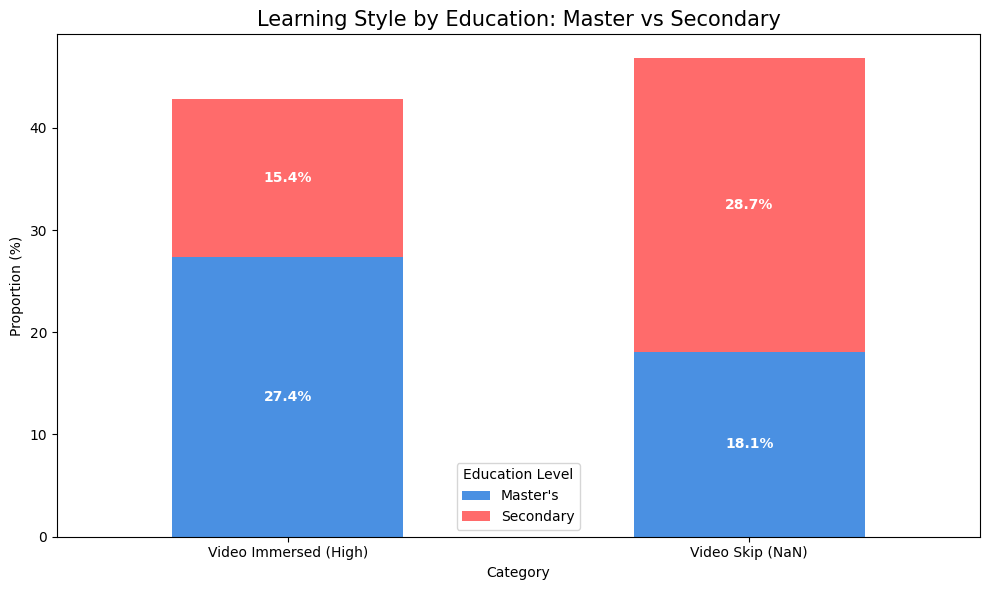

In [54]:
import matplotlib.pyplot as plt
import pandas as pd

data = {
    'Category': ['Video Immersed (High)', 'Video Skip (NaN)'],
    "Master's": [27.4, 18.1],
    'Secondary': [15.4, 28.7]
}
plot_df = pd.DataFrame(data).set_index('Category')

# 시각화
ax = plot_df.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#4A90E2', '#FF6B6B'])
plt.title('Learning Style by Education: Master vs Secondary', fontsize=15)
plt.ylabel('Proportion (%)')
plt.xticks(rotation=0)
plt.legend(title='Education Level')

# 수치 표시
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    ax.text(x+width/2, y+height/2, f'{height:.1f}%', ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

In [55]:
# 학력에 따른 학습 스타일 차이 검정
# 학력별 다른 학습 가이드 제공
!pip install scipy
from scipy.stats import chi2_contingency

from scipy import stats

# 그룹 복사 및 그룹 표시용 컬럼 추가 
v_high = video_high.copy()
v_zero = video_zero.copy()

v_high['group'] = 'High_Video'
v_zero['group'] = 'Zero_Video'

# 인덱스 무시하고 합치기 
compare_df = pd.concat([v_high, v_zero], ignore_index=True)

# 교차표(Contingency Table) 생성
contingency_table = pd.crosstab(compare_df['LoE_DI'], compare_df['group'])

# 카이제곱 검정 실시
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"카이제곱 통계량: {chi2:.4f}")
print(f"P-value: {p:.4e}")

if p < 0.05:
    print("결과: 학력에 따른 학습 스타일 차이는 통계적으로 매우 유의미함 (귀무가설 기각)")
else:
    print("결과: 학력과 학습 스타일 간의 유의미한 차이가 발견되지 않음")

카이제곱 통계량: 935.3384
P-value: 5.9774e-200
결과: 학력에 따른 학습 스타일 차이는 통계적으로 매우 유의미함 (귀무가설 기각)


In [56]:
### 수정 필요
from scipy.stats import mannwhitneyu
# 탐색 시도 후 이탈자 
churn_group_video = df[(df['viewed'] == 1) & (df['nevents'] > 0) & (df['explored'] == 0)]['nplay_video'].fillna(0)

# explored 된 유저
success_group_video = df[df['explored'] == 1]['nplay_video'].fillna(0)

# Mann-Whitney U 검정 실시
stat, p = mannwhitneyu(churn_group_video, success_group_video)

print("=== 이탈자 vs explored 유저 영상 재생 횟수 차이 검정 ===")
print(f"탐색 시도 후 이탈자 평균 영상 재생 횟수 : {churn_group_video.mean():.2f}회")
print(f"explored 유저 평균 영상 재생 횟수 : {success_group_video.mean():.2f}회")
print(f"P-value: {p:.4e}")

# 3. 결과 해석
if p < 0.05:
    print("\n 결과 : 두 집단 간 영상 재생 횟수 차이는 통계적으로 매우 유의미함")
    print(f" 인사이트 : explored 유저는 탐색 시도 후 이탈자보다 약 {success_group_video.mean()/churn_group_video.mean():.1f}배 더 많은 영상을 소비함")
else:
    print("\n 결과 : 두 집단 간 통계적으로 유의미한 차이가 발견되지 않음")

=== 이탈자 vs explored 유저 영상 재생 횟수 차이 검정 ===
탐색 시도 후 이탈자 평균 영상 재생 횟수 : 27.82회
explored 유저 평균 영상 재생 횟수 : 348.23회
P-value: 0.0000e+00

 결과 : 두 집단 간 영상 재생 횟수 차이는 통계적으로 매우 유의미함
 인사이트 : explored 유저는 탐색 시도 후 이탈자보다 약 12.5배 더 많은 영상을 소비함


- 이탈자들의 경우 30회 미만 구간에서 가장 많은 이탈 발생
- 영상 재생 10회, 20회 달성 시마다 푸시 알림, 학습 포인트 지급 등 심리적 완주 독려

In [57]:
# explored 유저 분석
df['grade'] = pd.to_numeric(df['grade'], errors='coerce')

target = df[df['explored'] == 1]
print("========== Explored 유저의 grade 통계 ==========")
print(target['grade'].describe())

========== Explored 유저의 grade 통계 ==========
count    36692.000000
mean         0.454398
std          0.389863
min          0.000000
25%          0.000000
50%          0.470000
75%          0.850000
max          1.010000
Name: grade, dtype: float64


explored 된 유저 중 시험 미응시 비율 : 2.11%



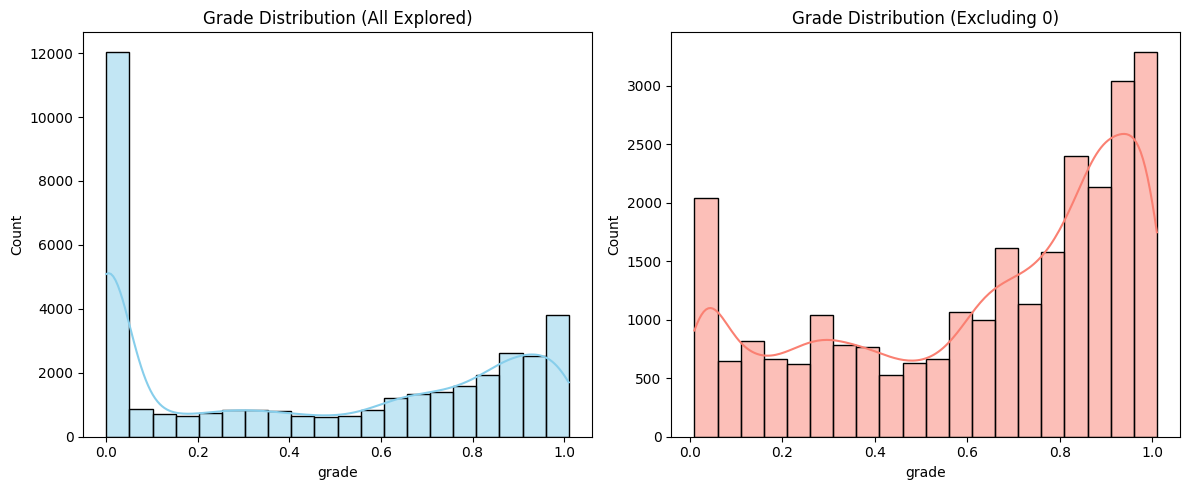

In [58]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# explored 된 유저 분석
target = df[df['explored'] == 1]
no_exam_rate = (len(target[target['exam_flag'] == 0]) / len(target)) * 100
print(f"explored 된 유저 중 시험 미응시 비율 : {no_exam_rate:.2f}%")
print()

# 시각화 (0점 포함 vs 0점 제외)
plt.figure(figsize=(12, 5))

# [왼쪽] 전체 분포 (0점 포함)
plt.subplot(1, 2, 1)
sns.histplot(target['grade'].dropna(), bins=20, color='skyblue', kde=True)
plt.title('Grade Distribution (All Explored)')

# [오른쪽] 실제 성취도 (0점 제외)
plt.subplot(1, 2, 2)
active_target = target[target['grade'] > 0]
sns.histplot(active_target['grade'], bins=20, color='salmon', kde=True)
plt.title('Grade Distribution (Excluding 0)')

plt.tight_layout()
plt.show()

- 본 서비스는 심화 학습자의 97.9%가 시험에 응시할 만큼 완주 의지가 높지만, 전체 유저의 88%가 초반 탐색 단계에서 이탈함
- 따라서 심화 학습자 관리보다는 초기 이탈 구간의 심리적/기술적 허들을 낮추는 온보딩 전략이 성장의 핵심 과제임
- grade 0이 많은 현상 : 학습의 질보다 양 / 시험 성적보다 정보 습득 / 평가에 대한 심리적 허들 / 평가에 참여할 동기 부족 

====================================================================================

### 이탈 유형 재정의

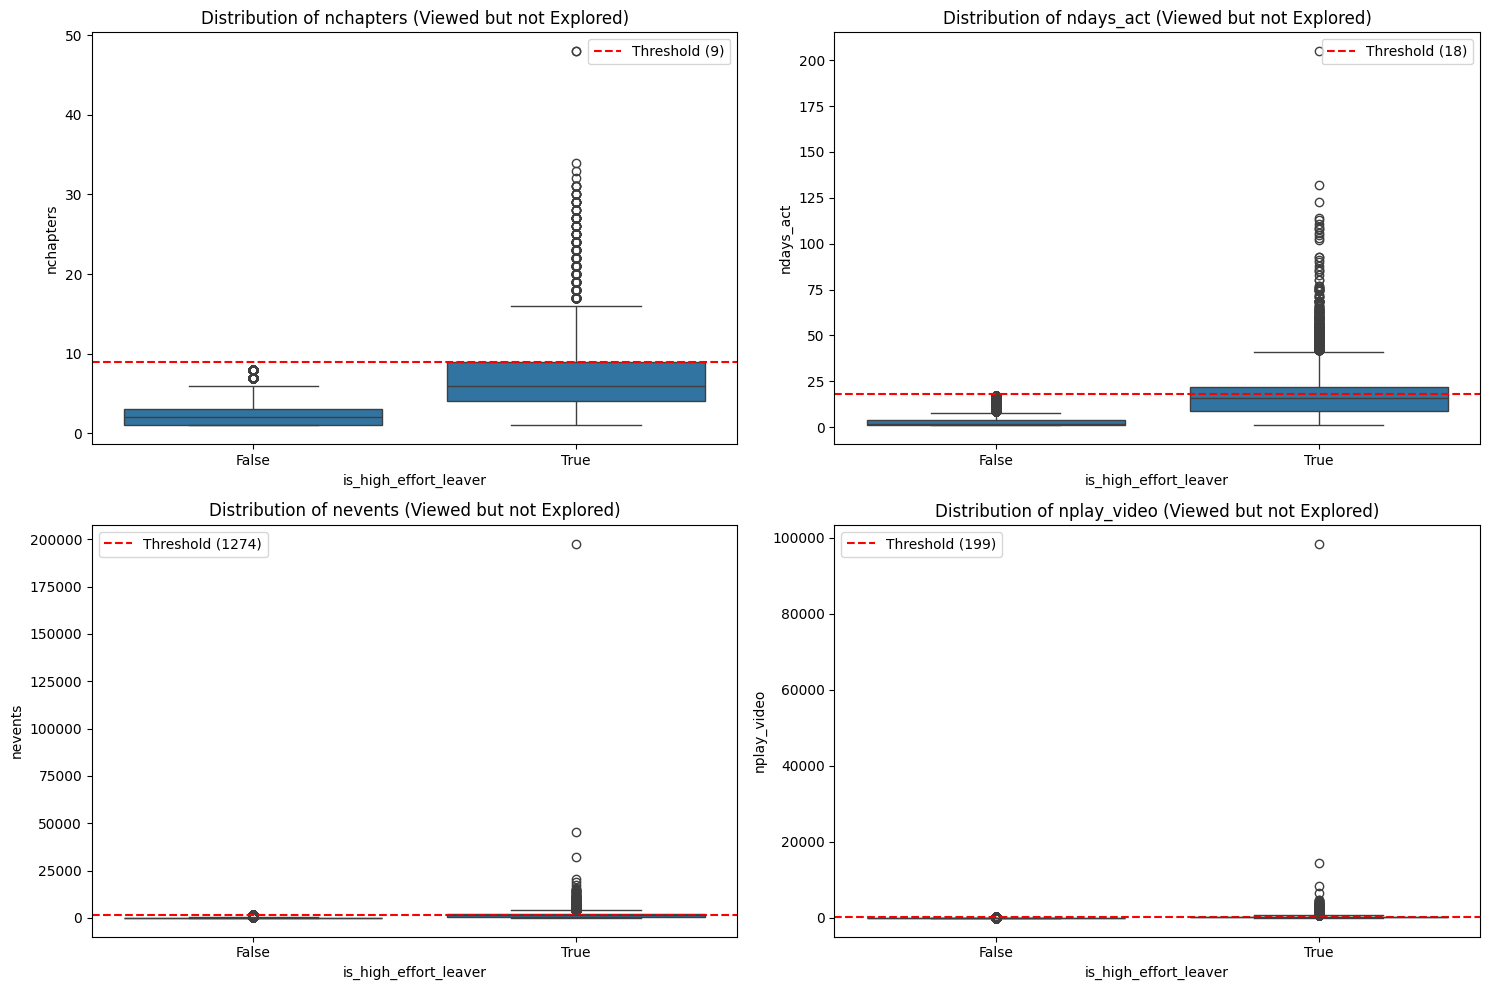

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

df = df.reset_index(drop=True)

# 임계값 설정
thresholds = {
    'nchapters': 9,
    'ndays_act': 18,
    'nevents': 1274,
    'nplay_video': 199
}

# step 2 유저 그룹 분류 
# viewed는 했지만 explored는 못한 유저들 중, 설정한 기준을 하나라도 넘긴 '고관여 탐색 이탈자' 추출
target_condition = (df['viewed'] == 1) & (df['explored'] == 0)
df['is_high_effort_leaver'] = target_condition & (
    (df['nchapters'] >= thresholds['nchapters']) | 
    (df['ndays_act'] >= thresholds['ndays_act']) |
    (df['nevents'] >= thresholds['nevents']) |
    (df['nplay_video'] >= thresholds['nplay_video'])
)

# 임계값 기준 분포 확인
features = ['nchapters', 'ndays_act', 'nevents', 'nplay_video']
plt.figure(figsize=(15, 10))

for i, col in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='is_high_effort_leaver', y=col, data=df[target_condition])
    plt.axhline(thresholds[col], color='red', linestyle='--', label=f'Threshold ({thresholds[col]})')
    plt.title(f'Distribution of {col} (Viewed but not Explored)')
    plt.legend()

plt.tight_layout()
plt.show()

In [60]:
# 이탈자 유형 세분화
# Step 1. 진입 전 이탈
r_step1 = ((df['registered'] == 1) & (df['viewed'] == 0)).sum()

# Step 2. 탐색 중 이탈
# 2-1. 단순 탐색 후 이탈 (기준치 미달)
r_step2_1 = ((df['viewed'] == 1) & (df['explored'] == 0) & (df['is_high_effort_leaver'] == False)).sum()

# 2-2. 고관여 탐색 후 이탈 (기준치 초과)
r_step2_2 = ((df['viewed'] == 1) & (df['explored'] == 0) & (df['is_high_effort_leaver'] == True)).sum()

print(f"진입 전 이탈 : {r_step1:,}명")
print(f"단순 탐색 후 이탈 : {r_step2_1:,}명")
print(f"고관여 탐색 후 이탈 : {r_step2_2:,}명")

진입 전 이탈 : 208,632명
단순 탐색 후 이탈 : 268,125명
고관여 탐색 후 이탈 : 19,652명


In [61]:
# Viewed -> Explored 단계 이탈자 중 고관여 탐색 유저의 비율
leaver_count = df[target_condition].shape[0]
high_effort_count = df['is_high_effort_leaver'].sum()
ratio = (high_effort_count / leaver_count) * 100

print(f"탐색 단계 이탈자 중 고관여 탐색 유저 비율: {ratio:.2f}%")

탐색 단계 이탈자 중 고관여 탐색 유저 비율: 6.83%


In [62]:
import numpy as np
from scipy import stats

# 고관여 탐색 이탈자들의 상당수가 많은 활동량에도 불구하고 9챕터 이상의 진도를 나가지 못하는 학습 정체 현상을 보임
# 탐색 단계 이탈자 중 활동이 아예 없는 유저는 효율성(nchapters/nevents) 계산 자체가 무의미하므로 제외
active_user = df[(df['nevents'] > 0) & (df['nevents'].notna()) & (df['nchapters'] > 0) & (df['nchapters'].notna()) & (df['viewed'] == 1) & (df['explored'] == 0)].copy()

# 효율성 지표 
active_user['learning_efficiency'] = active_user['nchapters'] / active_user['nevents']

# 그룹 나누기
group_high = active_user[active_user['is_high_effort_leaver'] == True]['learning_efficiency']
group_low = active_user[active_user['is_high_effort_leaver'] == False]['learning_efficiency']

# 통계 검정 (Mann-Whitney U)
u_stat, p_val = stats.mannwhitneyu(group_low, group_high, alternative='two-sided')

print(f"고관여 탐색 이탈자 효율성 평균: {group_high.mean():.4f}")
print(f"단순 탐색 이탈자 효율성 평균: {group_low.mean():.4f}")
print(f"P-value: {p_val:.10f}")
print()
if p_val < 0.05:
    ratio = group_low.mean() / group_high.mean()
    print(f"결과 : 학습 정체 현상이 통계적으로 매우 유의미하게 확인")
    print(f"효율성 분석 : 고관여 탐색 이탈자의 학습 효율은 단순 탐색 이탈자 대비 {1/ratio:.1%} 수준에 불과")
    print(f"결론 : 고관여 탐색 유저들은 동일 진도 달성을 위해 단순 탐색 유저들 보다 노력 대비 효율이 약 {ratio:.1f}배 낮음")

고관여 탐색 이탈자 효율성 평균: 0.0230
단순 탐색 이탈자 효율성 평균: 0.1075
P-value: 0.0000000000

결과 : 학습 정체 현상이 통계적으로 매우 유의미하게 확인
효율성 분석 : 고관여 탐색 이탈자의 학습 효율은 단순 탐색 이탈자 대비 21.4% 수준에 불과
결론 : 고관여 탐색 유저들은 동일 진도 달성을 위해 단순 탐색 유저들 보다 노력 대비 효율이 약 4.7배 낮음


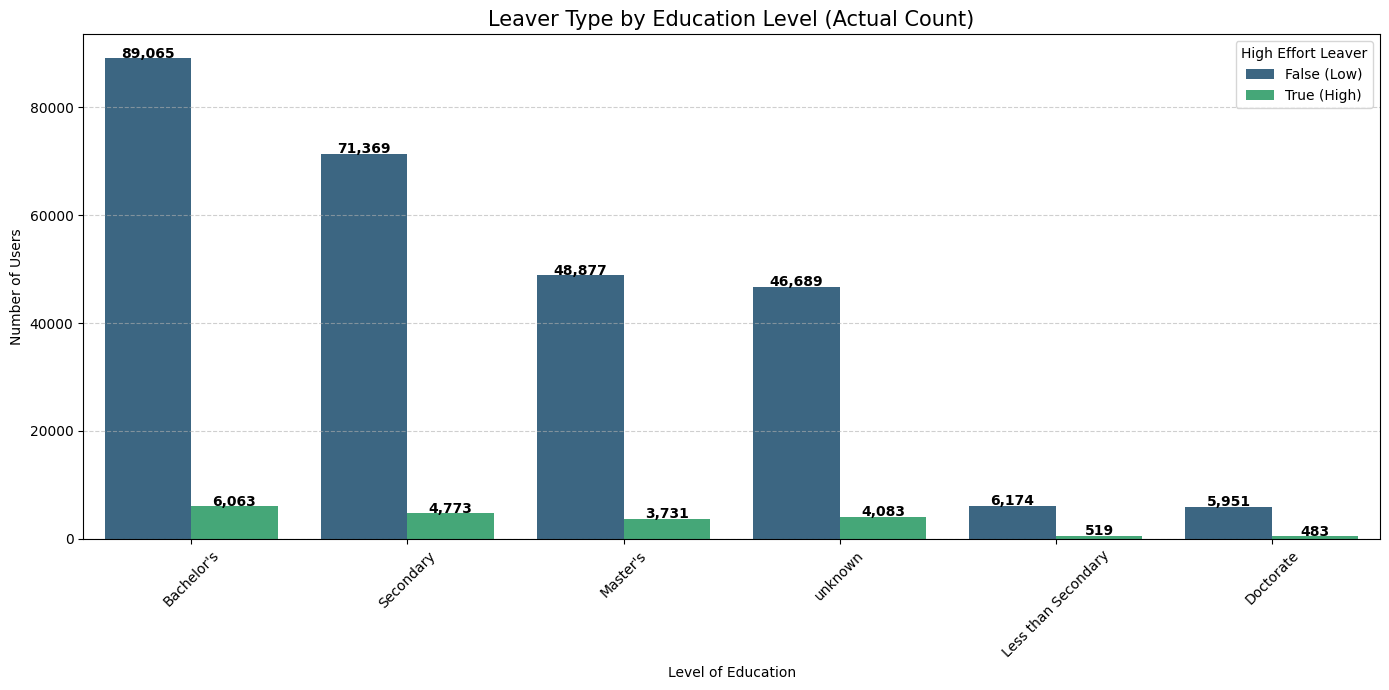

===== [학력별 이탈자 상세 수치] =====
                     Low_Effort_Count  High_Effort_Count  Total
LoE_DI                                                         
Bachelor's                      89065               6063  95128
Secondary                       71369               4773  76142
Master's                        48877               3731  52608
unknown                         46689               4083  50772
Less than Secondary              6174                519   6693
Doctorate                        5951                483   6434


In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
# 학력별 단순 탐색 / 고관여 탐색 이탈자 수 비교
leavers_df = df[(df['viewed'] == 1) & (df['explored'] == 0)].copy()

plt.figure(figsize=(14, 7))
ax = sns.countplot(x='LoE_DI', hue='is_high_effort_leaver', data=leavers_df, 
                   order=leavers_df['LoE_DI'].value_counts().index, palette='viridis')

# 막대 그래프 위에 실제 인원수 표시
for p in ax.patches:
    height = p.get_height()
    if height > 0: 
        ax.text(p.get_x() + p.get_width()/2., height + 100, 
                f'{int(height):,}',
                ha="center", fontsize=10, fontweight='bold')

plt.title('Leaver Type by Education Level (Actual Count)', fontsize=15)
plt.xlabel('Level of Education')
plt.ylabel('Number of Users')
plt.legend(title='High Effort Leaver', labels=['False (Low)', 'True (High)'])
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 실제 수치 요약 테이블 
count_table = pd.crosstab(leavers_df['LoE_DI'], leavers_df['is_high_effort_leaver'])
count_table.columns = ['Low_Effort_Count', 'High_Effort_Count']
count_table['Total'] = count_table.sum(axis=1)
count_table = count_table.sort_values(by='Total', ascending=False)

print("===== [학력별 이탈자 상세 수치] =====")
print(count_table)

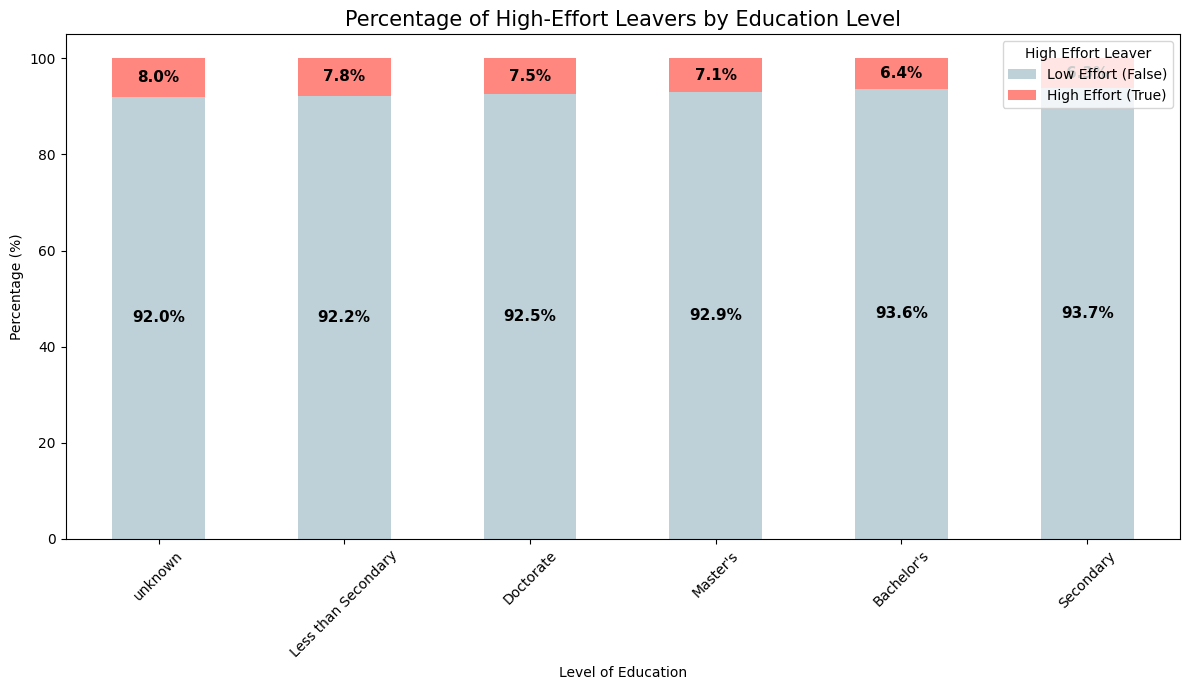

=== [학력별 고관여 이탈 비중] ===
LoE_DI
unknown                8.041834
Less than Secondary    7.754370
Doctorate              7.506994
Master's               7.092077
Bachelor's             6.373518
Secondary              6.268551
Name: True, dtype: float64


In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 학력별 이탈자 유형 비중 계산
# 각 학력 내에서 단순 탐색 대비 고관여 탐색의 비율을 직관적 비교
loe_pivot = pd.crosstab(leavers_df['LoE_DI'], leavers_df['is_high_effort_leaver'], normalize='index') * 100

# 고관여 이탈자 비중이 높은 순서대로 정렬
loe_pivot = loe_pivot.sort_values(by=True, ascending=False)

# 시각화: 100% 누적 막대 그래프
ax = loe_pivot.plot(kind='bar', stacked=True, figsize=(12, 7), color=['#aec6cf', '#ff6961'], alpha=0.8)

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 5: # 5% 이상일 때만 표시
        x, y = p.get_xy() 
        ax.text(x+width/2, y+height/2, f'{height:.1f}%', ha='center', va='center', fontsize=11, fontweight='bold')

plt.title('Percentage of High-Effort Leavers by Education Level', fontsize=15)
plt.ylabel('Percentage (%)')
plt.xlabel('Level of Education')
plt.legend(title='High Effort Leaver', labels=['Low Effort (False)', 'High Effort (True)'], loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 수치 요약
print("=== [학력별 고관여 이탈 비중] ===")
print(loe_pivot[True].head(6))

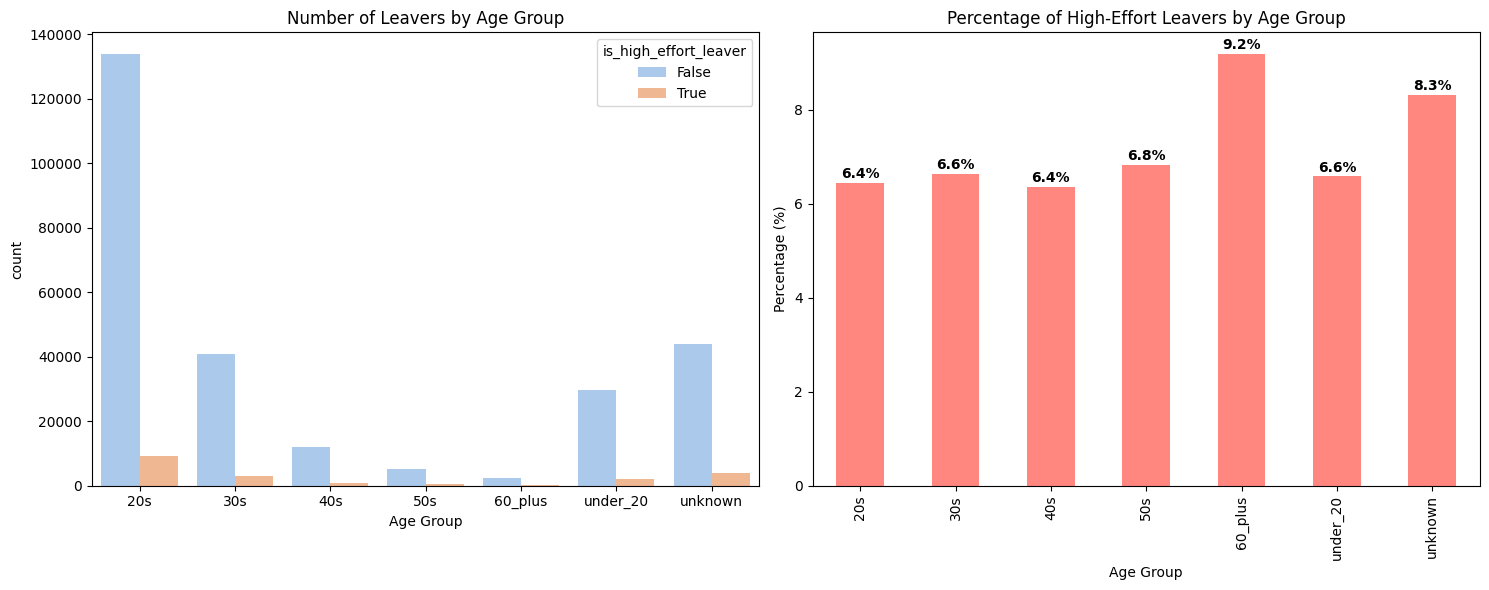

In [65]:
# 연령대별 고관여 탐색 이탈자 비중 
age_pivot = pd.crosstab(leavers_df['age_group'], leavers_df['is_high_effort_leaver'] == True, normalize='index') * 100
age_pivot = age_pivot.sort_index()

# 시각화 
plt.figure(figsize=(15, 6))

# 왼쪽: 연령대별 단순 인원수
plt.subplot(1, 2, 1)
sns.countplot(x='age_group', hue='is_high_effort_leaver', data=leavers_df, palette='pastel', order=sorted(leavers_df['age_group'].unique()))
plt.title('Number of Leavers by Age Group')
plt.xlabel('Age Group')

# 오른쪽: 연령대별 고관여 이탈 비중 (%)
plt.subplot(1, 2, 2)
age_pivot[True].plot(kind='bar', color='#ff6961', alpha=0.8)
plt.title('Percentage of High-Effort Leavers by Age Group')
plt.ylabel('Percentage (%)')
plt.xlabel('Age Group')

# 비중 수치 표시
for i, v in enumerate(age_pivot[True]):
    plt.text(i, v + 0.1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [66]:
# 연령대별 고관여 이탈자 인원수 확인
high_effort_counts = leavers_df[leavers_df['is_high_effort_leaver'] == True]['age_group'].value_counts()
print(high_effort_counts)

age_group
20s         9216
unknown     3990
30s         2908
under_20    2089
40s          818
50s          387
60_plus      244
Name: count, dtype: int64


In [67]:
# 20대 고관여 이탈자들만 필터링해서 이벤트 발생 패턴 보기
young_stuck = leavers_df[(leavers_df['age_group'] == '20s') & (leavers_df['is_high_effort_leaver'] == True)]

print(f"20대 고관여 이탈자 평균 영상 재생 수: {young_stuck['nplay_video'].mean():.1f}회")
print(f"20대 고관여 이탈자 평균 이벤트 발생 수: {young_stuck['nevents'].mean():.1f}회")
print(f"20대 고관여 이탈자 평균 챕터 수 : {young_stuck['nchapters'].mean():.1f}개")
print(f"20대 고관여 이탈자 평균 활동일 : {young_stuck['ndays_act'].mean():.1f}일")

20대 고관여 이탈자 평균 영상 재생 수: 284.5회
20대 고관여 이탈자 평균 이벤트 발생 수: 1537.4회
20대 고관여 이탈자 평균 챕터 수 : 6.6개
20대 고관여 이탈자 평균 활동일 : 16.0일


In [68]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# # 활동량 대비 단순 탐색 / 고관여 탐색 이탈자 성적 분포 
# # 시험 미응시자를 제외해야 '노력 대비 성취'라는 순수한 상관관계를 볼 수 있기에 시험을 치른 유저 중 성적 데이터가 있는 경우만 필터링
# grade_analysis1 = leavers_df[(leavers_df['exam_flag'] == 1) & (leavers_df['grade'].notna())].copy()
# grade_analysis_filtered1 = grade_analysis1[
#     (grade_analysis1['nevents'] < 197757) & 
#     (grade_analysis1['nevents'] > 0) & 
#     (grade_analysis1['nevents'].notna())
# ].copy()
# plt.figure(figsize=(12, 8))

# # 활동량과 성적의 상관관계
# sns.scatterplot(data=grade_analysis_filtered1, x='nevents', y='grade', 
#                 hue='is_high_effort_leaver', alpha=0.4, 
#                 palette={True: '#ff6961', False: '#aec6cf'})

# sns.kdeplot(data=grade_analysis_filtered1, x='nevents', y='grade', 
#             hue='is_high_effort_leaver', levels=5, thresh=0.2, alpha=0.3)

# plt.title('Activity (nevents) vs Grade Distribution (Filtered)', fontsize=15)
# plt.xlabel('Total Events (Activity)')
# plt.ylabel('Exam Grade')
# plt.axhline(y=grade_analysis_filtered1['grade'].mean(), color='gray', linestyle='--', label='Overall Avg Grade')
# plt.legend(title='High Effort Leaver')
# plt.show()

# # 활동량-성적 상관계수(r) 계산
# event_grade_corr = grade_analysis_filtered1.groupby('is_high_effort_leaver').apply(
#     lambda x: x['nevents'].corr(x['grade'])
# )

# print("\n===== [활동량(nevents) - 성적(grade) 상관계수(r)] =====")
# print(event_grade_corr)

# # 그룹별 성적 통계 요약
# print("===== [시험 응시자 그룹별 성적/활동량 요약] =====")
# summary_stats = grade_analysis_filtered1.groupby('is_high_effort_leaver')[['grade', 'nevents']].agg(['count', 'mean', 'median', 'std'])
# print(summary_stats)

In [69]:
# # 순위 데이터로 변환
# grade_analysis_filtered1['nevents_rank'] = grade_analysis_filtered1['nevents'].rank()
# grade_analysis_filtered1['grade_rank'] = grade_analysis_filtered1['grade'].rank()

# plt.figure(figsize=(12, 8))

# # 순위 데이터로 산점도 
# sns.scatterplot(data=grade_analysis_filtered1, x='nevents_rank', y='grade_rank', 
#                 hue='is_high_effort_leaver', alpha=0.3, 
#                 palette={True: '#ff6961', False: '#aec6cf'})

# # 경향성 확인을 위한 회귀선 추가 
# sns.regplot(data=grade_analysis_filtered1, x='nevents_rank', y='grade_rank', 
#             scatter=False, color='gray', label='Trend Line (Rank)')

# plt.title('Activity Rank vs Grade Rank (Spearman Logic Viz)', fontsize=15)
# plt.xlabel('Rank of Total Events')
# plt.ylabel('Rank of Exam Grade')
# plt.legend()
# plt.show()

# event_grade_corr_spearman = grade_analysis_filtered1.groupby('is_high_effort_leaver').apply(
#     lambda x: x['nevents'].corr(x['grade'], method='spearman')
# )

# # 스피어만 상관계수  
# print("\n===== [활동량(nevents) - 성적(grade) 스피어만 상관계수] =====")
# print(event_grade_corr_spearman)

In [70]:
# # 상관계수 데이터를 DataFrame으로 변환
# corr_df = event_grade_corr_spearman.reset_index()
# corr_df.columns = ['Leaver Type', 'Spearman Correlation']
# corr_df['Leaver Type'] = corr_df['Leaver Type'].map({True: 'High Effort', False: 'Low Effort'})

# plt.figure(figsize=(10, 6))

# # 바 차트
# bars = sns.barplot(data=corr_df, x='Leaver Type', y='Spearman Correlation', 
#                    palette={'High Effort': '#ff6961', 'Low Effort': '#aec6cf'})

# # 수치 표시 및 가이드라인 추가
# for bar in bars.patches:
#     yval = bar.get_height()
#     plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'r = {yval:.4f}', ha='center', fontweight='bold', fontsize=13)

# plt.axhline(0.5, color='gray', linestyle='--') # 0.5선 기준
# plt.text(0.5, 0.51, 'Moderate Correlation (0.5)', color='gray', fontsize=10)

# plt.title('Spearman Correlation: Activity vs Grade by Leaver Type', fontsize=15)
# plt.ylabel('Spearman Correlation (r)')
# plt.ylim(0, 0.6) 
# plt.show()

In [71]:
# # 효율성 대비 단순 탐색 / 고관여 탐색 이탈자 성적 산점도
# # 시험 미응시자를 제외해야 '노력 대비 성취'라는 순수한 상관관계를 볼 수 있기에 시험을 치른 유저 중 성적 데이터가 있는 경우만 필터링
# grade_analysis1 = leavers_df[(leavers_df['exam_flag'] == 1) & (leavers_df['grade'].notna())].copy()
# grade_analysis_filtered2 = grade_analysis1[
#     (grade_analysis1['nevents'] < 197757) & 
#     (grade_analysis1['nevents'] > 0) & 
#     (grade_analysis1['nevents'].notna()) & 
#     (grade_analysis1['nchapters'] > 0) & 
#     (grade_analysis1['nchapters'].notna())
# ].copy()

# # 효율성 지표 
# grade_analysis_filtered2['learning_efficiency'] = grade_analysis_filtered2['nchapters'] / grade_analysis_filtered2['nevents']

# # 효율성 대비 성적 분포
# plt.figure(figsize=(12, 8))
# sns.scatterplot(data=grade_analysis_filtered2, x='learning_efficiency', y='grade', 
#                 hue='is_high_effort_leaver', alpha=0.5,
#                 palette={True: '#ff6961', False: '#aec6cf'})

# # 상관계수 (효율성 vs 성적)
# eff_corr_high = grade_analysis_filtered2[grade_analysis_filtered2['is_high_effort_leaver'] == True][['learning_efficiency', 'grade']].corr().iloc[0, 1]
# eff_corr_low = grade_analysis_filtered2[grade_analysis_filtered2['is_high_effort_leaver'] == False][['learning_efficiency', 'grade']].corr().iloc[0, 1]

# plt.title('Learning Efficiency vs Exam Grade', fontsize=15)
# plt.xlabel('Efficiency (Chapters per Event)')
# plt.ylabel('Exam Grade')
# plt.show()

# # 상관계수(r) 및 기초 통계 확인
# eff_corr = grade_analysis_filtered2.groupby('is_high_effort_leaver').apply(
#     lambda x: x['learning_efficiency'].corr(x['grade'])
# )
# print("\n===== [효율성(nchapters / nevents) - 성적(grade) 상관계수(r)] =====")
# print(f"상관계수(r):\n{eff_corr}")
# print("\n[시험 응시자 그룹별 성적/효율성 요약]")
# summary_stats2 = grade_analysis_filtered2.groupby('is_high_effort_leaver')[['grade', 'learning_efficiency']].agg(['count', 'mean', 'median', 'std'])
# print(summary_stats2)

----------

### nchapters 제외 이탈 유형 재정의

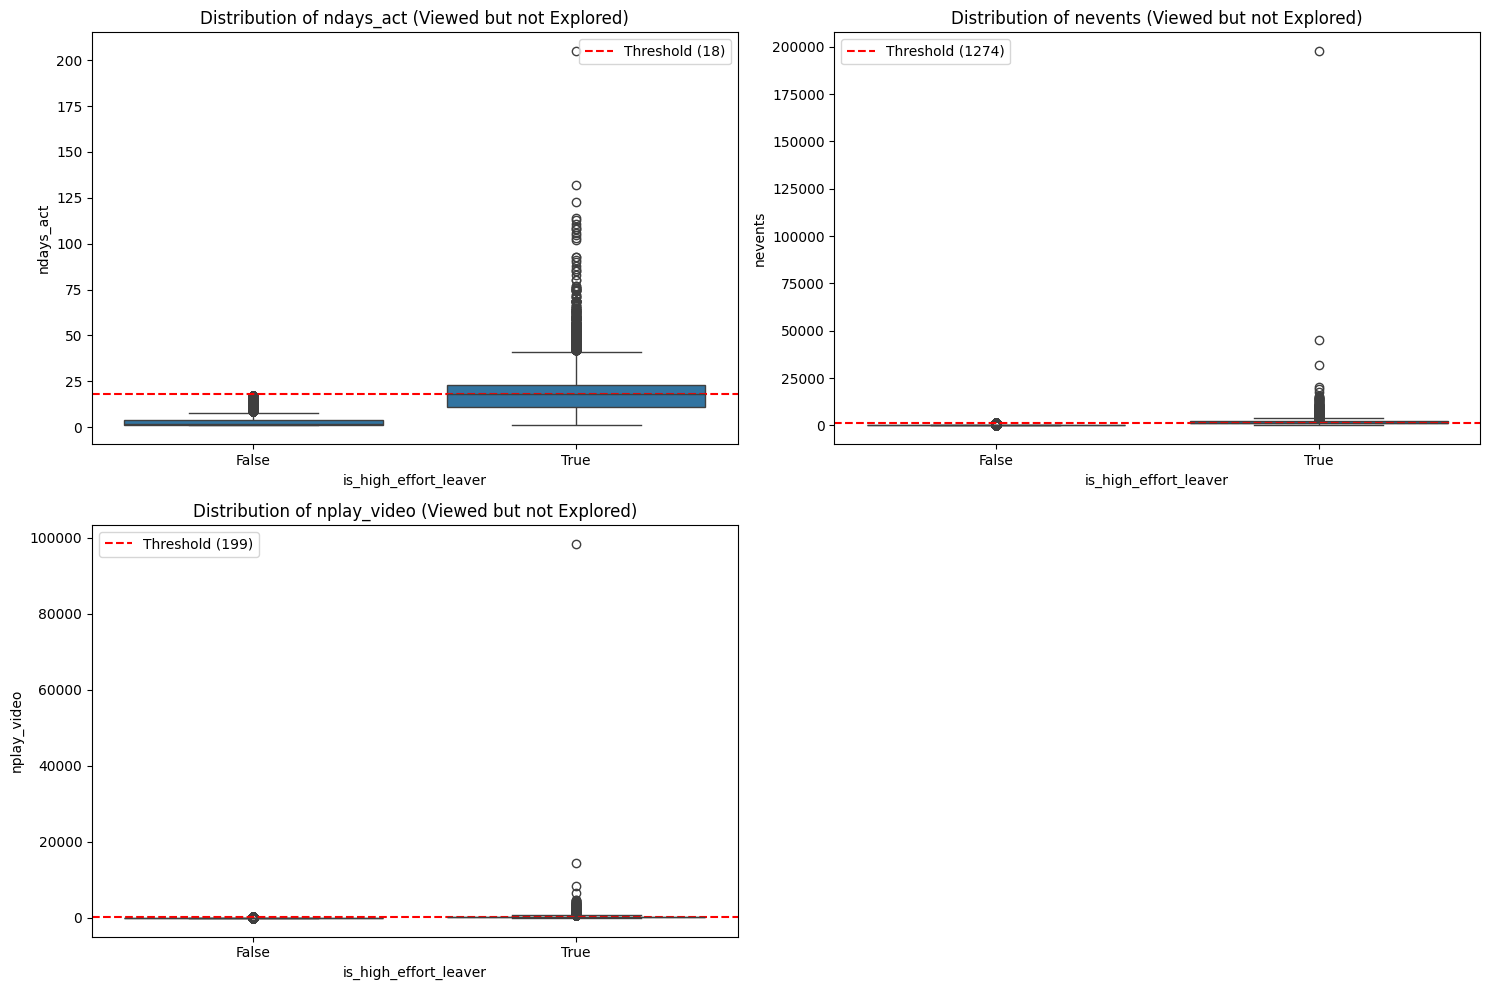

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

df = df.reset_index(drop=True)

# 임계값 설정
thresholds = {
    'ndays_act': 18,
    'nevents': 1274,
    'nplay_video': 199
}

# step 2 유저 그룹 분류 
# viewed는 했지만 explored는 못한 유저들 중, 설정한 기준을 하나라도 넘긴 '고관여 탐색 이탈자' 추출
target_condition = (df['viewed'] == 1) & (df['explored'] == 0)
df['is_high_effort_leaver'] = target_condition & ( 
    (df['ndays_act'] >= thresholds['ndays_act']) |
    (df['nevents'] >= thresholds['nevents']) |
    (df['nplay_video'] >= thresholds['nplay_video'])
)

# 임계값 기준 분포 확인
features = ['ndays_act', 'nevents', 'nplay_video']
plt.figure(figsize=(15, 10))

for i, col in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='is_high_effort_leaver', y=col, data=df[target_condition])
    plt.axhline(thresholds[col], color='red', linestyle='--', label=f'Threshold ({thresholds[col]})')
    plt.title(f'Distribution of {col} (Viewed but not Explored)')
    plt.legend()

plt.tight_layout()
plt.show()

In [73]:
# 이탈자 유형 세분화
# Step 1. 진입 전 이탈
r_step1 = ((df['registered'] == 1) & (df['viewed'] == 0)).sum()

# Step 2. 탐색 중 이탈
# 2-1. 단순 탐색 후 이탈 (기준치 미달)
r_step2_1 = ((df['viewed'] == 1) & (df['explored'] == 0) & (df['is_high_effort_leaver'] == False)).sum()

# 2-2. 고관여 탐색 후 이탈 (기준치 초과)
r_step2_2 = ((df['viewed'] == 1) & (df['explored'] == 0) & (df['is_high_effort_leaver'] == True)).sum()

print(f"진입 전 이탈 : {r_step1:,}명")
print(f"단순 탐색 후 이탈 : {r_step2_1:,}명")
print(f"고관여 탐색 후 이탈 : {r_step2_2:,}명")

진입 전 이탈 : 208,632명
단순 탐색 후 이탈 : 271,397명
고관여 탐색 후 이탈 : 16,380명


In [74]:
# Viewed -> Explored 단계 이탈자 중 고관여 탐색 유저의 비율
leaver_count = df[target_condition].shape[0]
high_effort_count = df['is_high_effort_leaver'].sum()
ratio = (high_effort_count / leaver_count) * 100

print(f"탐색 단계 이탈자 중 고관여 탐색 유저 비율: {ratio:.2f}%")

탐색 단계 이탈자 중 고관여 탐색 유저 비율: 5.69%


In [75]:
import numpy as np
from scipy import stats

# 고관여 탐색 이탈자들의 상당수가 많은 활동량에도 불구하고 9챕터 이상의 진도를 나가지 못하는 학습 정체 현상을 보임
# 탐색 단계 이탈자 중 활동이 아예 없는 유저는 효율성(nchapters/nevents) 계산 자체가 무의미하므로 제외
active_user = df[(df['nevents'] > 0) & (df['nevents'].notna()) & (df['nchapters'] > 0) & (df['nchapters'].notna()) & (df['viewed'] == 1) & (df['explored'] == 0)].copy()

# 효율성 지표 
active_user['learning_efficiency'] = active_user['nchapters'] / active_user['nevents']

# 그룹 나누기
group_high = active_user[active_user['is_high_effort_leaver'] == True]['learning_efficiency']
group_low = active_user[active_user['is_high_effort_leaver'] == False]['learning_efficiency']

# 통계 검정 (Mann-Whitney U)
u_stat, p_val = stats.mannwhitneyu(group_low, group_high, alternative='two-sided')

print(f"고관여 탐색 이탈자 효율성 평균: {group_high.mean():.4f}")
print(f"단순 탐색 이탈자 효율성 평균: {group_low.mean():.4f}")
print(f"P-value: {p_val:.10f}")
print()
if p_val < 0.05:
    ratio = group_low.mean() / group_high.mean()
    print(f"결과 : 학습 정체 현상이 통계적으로 매우 유의미하게 확인")
    print(f"효율성 분석 : 고관여 탐색 이탈자의 학습 효율은 단순 탐색 이탈자 대비 {1/ratio:.1%} 수준에 불과")
    print(f"결론 : 고관여 탐색 유저들은 동일 진도 달성을 위해 단순 탐색 유저들 보다 노력 대비 효율이 약 {ratio:.1f}배 낮음")

고관여 탐색 이탈자 효율성 평균: 0.0053
단순 탐색 이탈자 효율성 평균: 0.1075
P-value: 0.0000000000

결과 : 학습 정체 현상이 통계적으로 매우 유의미하게 확인
효율성 분석 : 고관여 탐색 이탈자의 학습 효율은 단순 탐색 이탈자 대비 4.9% 수준에 불과
결론 : 고관여 탐색 유저들은 동일 진도 달성을 위해 단순 탐색 유저들 보다 노력 대비 효율이 약 20.4배 낮음


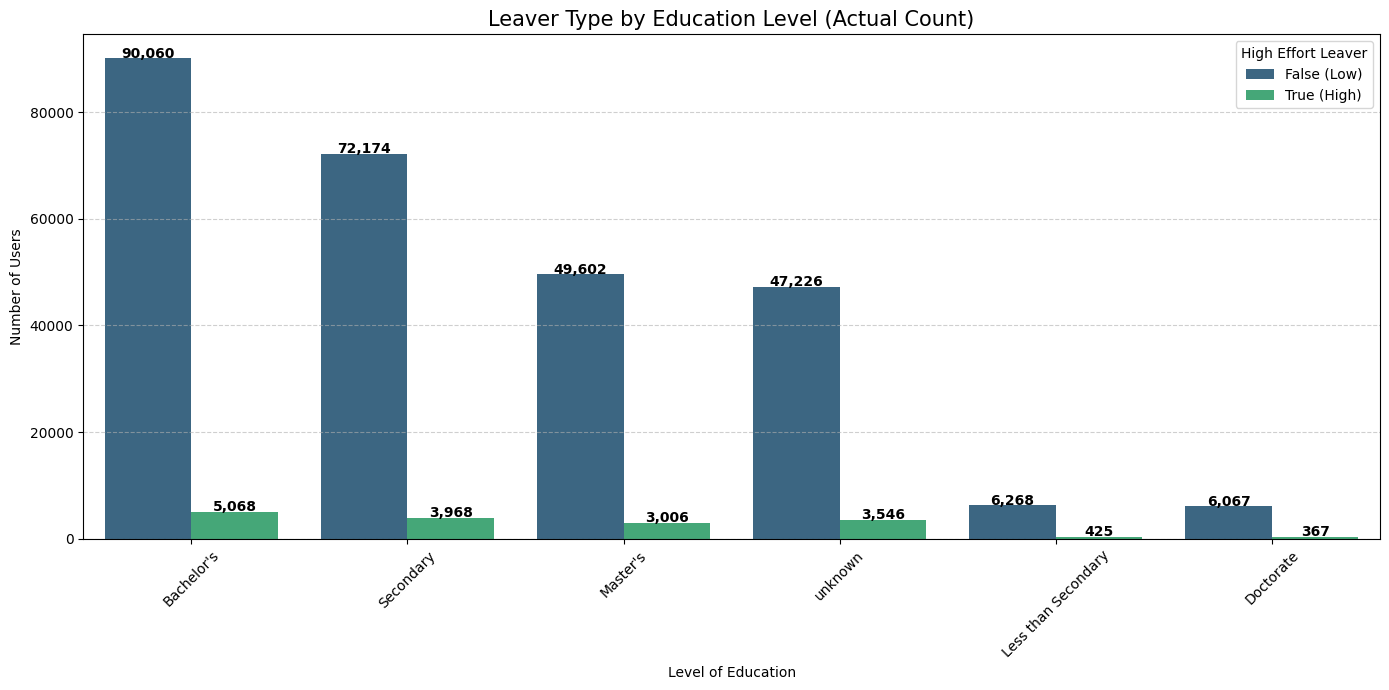

===== [학력별 이탈자 상세 수치] =====
                     Low_Effort_Count  High_Effort_Count  Total
LoE_DI                                                         
Bachelor's                      90060               5068  95128
Secondary                       72174               3968  76142
Master's                        49602               3006  52608
unknown                         47226               3546  50772
Less than Secondary              6268                425   6693
Doctorate                        6067                367   6434


In [76]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
# 학력별 단순 탐색 / 고관여 탐색 이탈자 수 비교
leavers_df = df[(df['viewed'] == 1) & (df['explored'] == 0)].copy()

plt.figure(figsize=(14, 7))
ax = sns.countplot(x='LoE_DI', hue='is_high_effort_leaver', data=leavers_df, 
                   order=leavers_df['LoE_DI'].value_counts().index, palette='viridis')

# 막대 그래프 위에 실제 인원수 표시
for p in ax.patches:
    height = p.get_height()
    if height > 0: 
        ax.text(p.get_x() + p.get_width()/2., height + 100, 
                f'{int(height):,}',
                ha="center", fontsize=10, fontweight='bold')

plt.title('Leaver Type by Education Level (Actual Count)', fontsize=15)
plt.xlabel('Level of Education')
plt.ylabel('Number of Users')
plt.legend(title='High Effort Leaver', labels=['False (Low)', 'True (High)'])
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 실제 수치 요약 테이블 
count_table = pd.crosstab(leavers_df['LoE_DI'], leavers_df['is_high_effort_leaver'])
count_table.columns = ['Low_Effort_Count', 'High_Effort_Count']
count_table['Total'] = count_table.sum(axis=1)
count_table = count_table.sort_values(by='Total', ascending=False)

print("===== [학력별 이탈자 상세 수치] =====")
print(count_table)

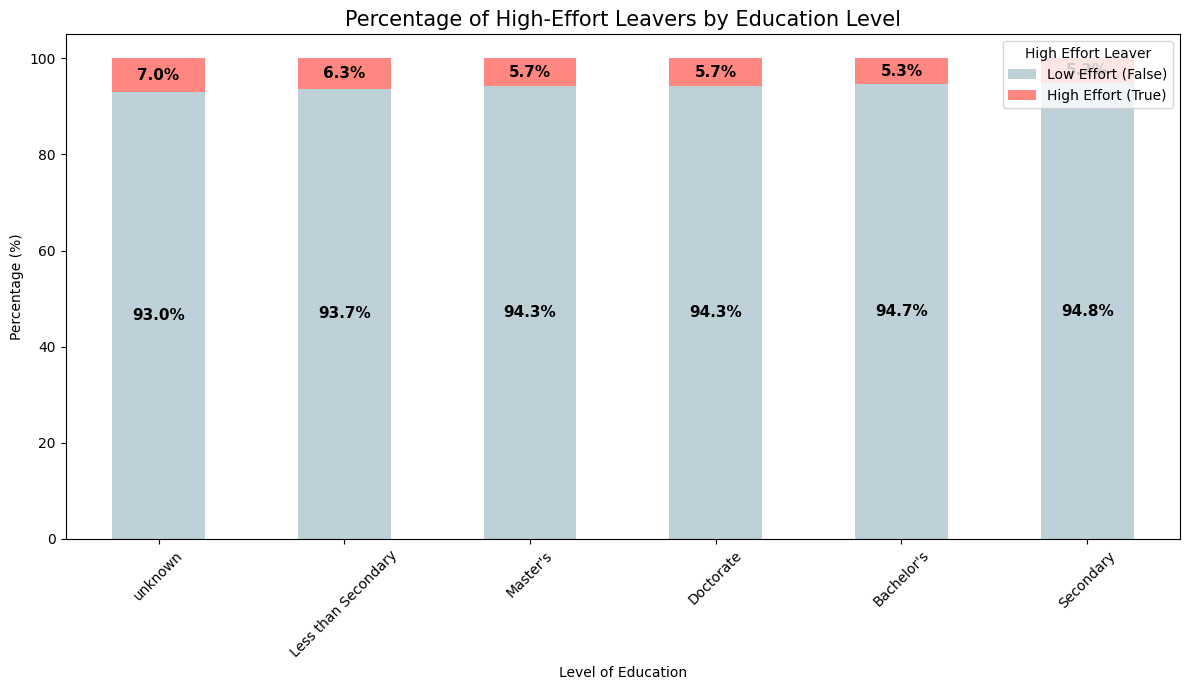

=== [학력별 고관여 이탈 비중] ===
LoE_DI
unknown                6.984165
Less than Secondary    6.349918
Master's               5.713960
Doctorate              5.704072
Bachelor's             5.327559
Secondary              5.211316
Name: True, dtype: float64


In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 학력별 이탈자 유형 비중 계산
# 각 학력 내에서 단순 탐색 대비 고관여 탐색의 비율을 직관적 비교
loe_pivot = pd.crosstab(leavers_df['LoE_DI'], leavers_df['is_high_effort_leaver'], normalize='index') * 100

# 고관여 이탈자 비중이 높은 순서대로 정렬
loe_pivot = loe_pivot.sort_values(by=True, ascending=False)

# 시각화: 100% 누적 막대 그래프
ax = loe_pivot.plot(kind='bar', stacked=True, figsize=(12, 7), color=['#aec6cf', '#ff6961'], alpha=0.8)

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 5: # 5% 이상일 때만 표시
        x, y = p.get_xy() 
        ax.text(x+width/2, y+height/2, f'{height:.1f}%', ha='center', va='center', fontsize=11, fontweight='bold')

plt.title('Percentage of High-Effort Leavers by Education Level', fontsize=15)
plt.ylabel('Percentage (%)')
plt.xlabel('Level of Education')
plt.legend(title='High Effort Leaver', labels=['Low Effort (False)', 'High Effort (True)'], loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 수치 요약
print("=== [학력별 고관여 이탈 비중] ===")
print(loe_pivot[True].head(6))

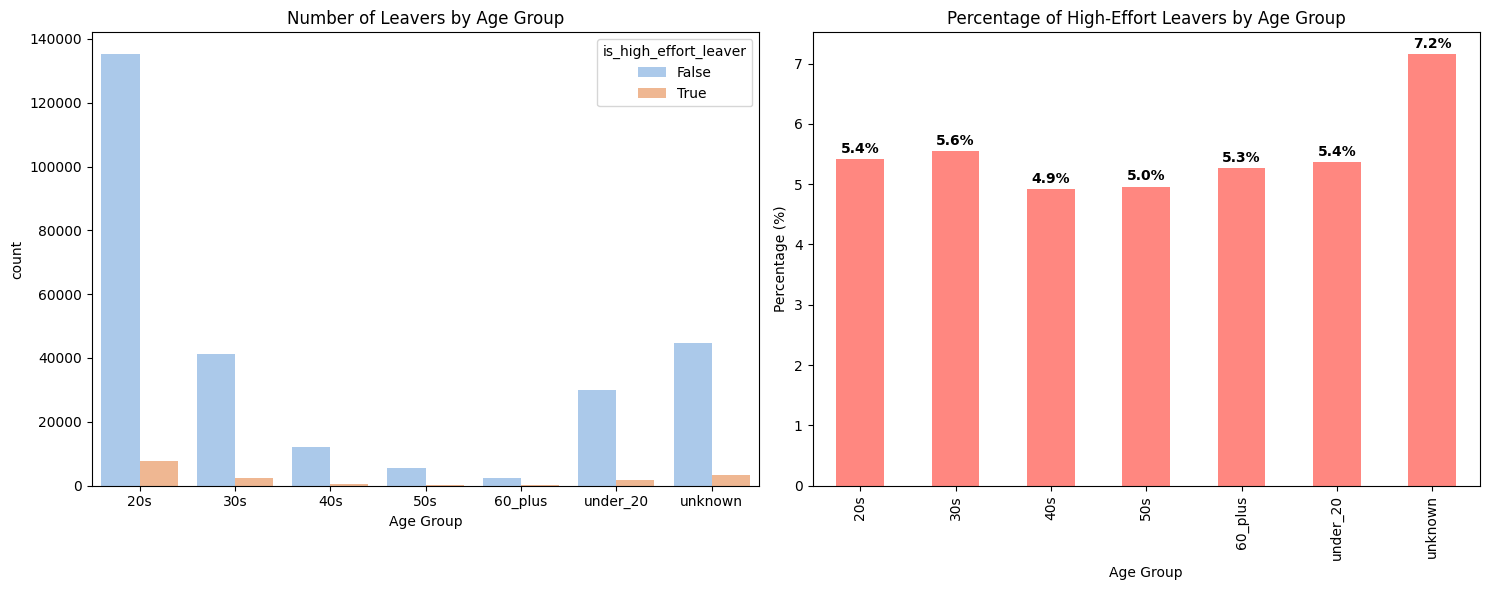

In [78]:
# 연령대별 고관여 탐색 이탈자 비중 
age_pivot = pd.crosstab(leavers_df['age_group'], leavers_df['is_high_effort_leaver'] == True, normalize='index') * 100
age_pivot = age_pivot.sort_index()

# 시각화 
plt.figure(figsize=(15, 6))

# 왼쪽: 연령대별 단순 인원수
plt.subplot(1, 2, 1)
sns.countplot(x='age_group', hue='is_high_effort_leaver', data=leavers_df, palette='pastel', order=sorted(leavers_df['age_group'].unique()))
plt.title('Number of Leavers by Age Group')
plt.xlabel('Age Group')

# 오른쪽: 연령대별 고관여 이탈 비중 (%)
plt.subplot(1, 2, 2)
age_pivot[True].plot(kind='bar', color='#ff6961', alpha=0.8)
plt.title('Percentage of High-Effort Leavers by Age Group')
plt.ylabel('Percentage (%)')
plt.xlabel('Age Group')

# 비중 수치 표시
for i, v in enumerate(age_pivot[True]):
    plt.text(i, v + 0.1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [79]:
# 연령대별 고관여 이탈자 인원수 확인
high_effort_counts = leavers_df[leavers_df['is_high_effort_leaver'] == True]['age_group'].value_counts()
print(high_effort_counts)

age_group
20s         7751
unknown     3435
30s         2435
under_20    1705
40s          633
50s          281
60_plus      140
Name: count, dtype: int64


In [80]:
# 20대 고관여 이탈자들만 필터링해서 이벤트 발생 패턴 보기
young_stuck = leavers_df[(leavers_df['age_group'] == '20s') & (leavers_df['is_high_effort_leaver'] == True)]

print(f"20대 고관여 이탈자 평균 영상 재생 수: {young_stuck['nplay_video'].mean():.1f}회")
print(f"20대 고관여 이탈자 평균 이벤트 발생 수: {young_stuck['nevents'].mean():.1f}회")
print(f"20대 고관여 이탈자 평균 활동일 : {young_stuck['ndays_act'].mean():.1f}일")

20대 고관여 이탈자 평균 영상 재생 수: 292.6회
20대 고관여 이탈자 평균 이벤트 발생 수: 1755.2회
20대 고관여 이탈자 평균 활동일 : 17.6일


In [81]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# # 활동량 대비 단순 탐색 / 고관여 탐색 이탈자 성적 분포 
# # 시험 미응시자를 제외해야 '노력 대비 성취'라는 순수한 상관관계를 볼 수 있기에 시험을 치른 유저 중 성적 데이터가 있는 경우만 필터링
# grade_analysis1 = leavers_df[(leavers_df['exam_flag'] == 1) & (leavers_df['grade'].notna())].copy()
# grade_analysis_filtered1 = grade_analysis1[
#     (grade_analysis1['nevents'] < 197757) & 
#     (grade_analysis1['nevents'] > 0) & 
#     (grade_analysis1['nevents'].notna())
# ].copy()
# plt.figure(figsize=(12, 8))

# # 활동량과 성적의 상관관계
# sns.scatterplot(data=grade_analysis_filtered1, x='nevents', y='grade', 
#                 hue='is_high_effort_leaver', alpha=0.4, 
#                 palette={True: '#ff6961', False: '#aec6cf'})

# sns.kdeplot(data=grade_analysis_filtered1, x='nevents', y='grade', 
#             hue='is_high_effort_leaver', levels=5, thresh=0.2, alpha=0.3)

# plt.title('Activity (nevents) vs Grade Distribution (Filtered)', fontsize=15)
# plt.xlabel('Total Events (Activity)')
# plt.ylabel('Exam Grade')
# plt.axhline(y=grade_analysis_filtered1['grade'].mean(), color='gray', linestyle='--', label='Overall Avg Grade')
# plt.legend(title='High Effort Leaver')
# plt.show()

# # 활동량-성적 상관계수(r) 계산
# event_grade_corr = grade_analysis_filtered1.groupby('is_high_effort_leaver').apply(
#     lambda x: x['nevents'].corr(x['grade'])
# )

# print("\n===== [활동량(nevents) - 성적(grade) 상관계수(r)] =====")
# print(event_grade_corr)

# # 그룹별 성적 통계 요약
# print("===== [시험 응시자 그룹별 성적/활동량 요약] =====")
# summary_stats = grade_analysis_filtered1.groupby('is_high_effort_leaver')[['grade', 'nevents']].agg(['count', 'mean', 'median', 'std'])
# print(summary_stats)

In [82]:
# # 상관계수 데이터를 DataFrame으로 변환
# corr_df = event_grade_corr_spearman.reset_index()
# corr_df.columns = ['Leaver Type', 'Spearman Correlation']
# corr_df['Leaver Type'] = corr_df['Leaver Type'].map({True: 'High Effort', False: 'Low Effort'})

# plt.figure(figsize=(10, 6))

# # 바 차트
# bars = sns.barplot(data=corr_df, x='Leaver Type', y='Spearman Correlation', 
#                    palette={'High Effort': '#ff6961', 'Low Effort': '#aec6cf'})

# # 수치 표시 및 가이드라인 추가
# for bar in bars.patches:
#     yval = bar.get_height()
#     plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'r = {yval:.4f}', ha='center', fontweight='bold', fontsize=13)

# plt.axhline(0.5, color='gray', linestyle='--') # 0.5선 기준
# plt.text(0.5, 0.51, 'Moderate Correlation (0.5)', color='gray', fontsize=10)

# plt.title('Spearman Correlation: Activity vs Grade by Leaver Type', fontsize=15)
# plt.ylabel('Spearman Correlation (r)')
# plt.ylim(0, 0.6) 
# plt.show()

In [83]:
# # 효율성 대비 단순 탐색 / 고관여 탐색 이탈자 성적 산점도
# # 시험 미응시자를 제외해야 '노력 대비 성취'라는 순수한 상관관계를 볼 수 있기에 시험을 치른 유저 중 성적 데이터가 있는 경우만 필터링
# grade_analysis1 = leavers_df[(leavers_df['exam_flag'] == 1) & (leavers_df['grade'].notna())].copy()
# grade_analysis_filtered2 = grade_analysis1[
#     (grade_analysis1['nevents'] < 197757) & 
#     (grade_analysis1['nevents'] > 0) & 
#     (grade_analysis1['nevents'].notna()) & 
#     (grade_analysis1['nchapters'] > 0) & 
#     (grade_analysis1['nchapters'].notna())
# ].copy()

# # 효율성 지표 
# grade_analysis_filtered2['learning_efficiency'] = grade_analysis_filtered2['nchapters'] / grade_analysis_filtered2['nevents']

# # 효율성 대비 성적 분포
# plt.figure(figsize=(12, 8))
# sns.scatterplot(data=grade_analysis_filtered2, x='learning_efficiency', y='grade', 
#                 hue='is_high_effort_leaver', alpha=0.5,
#                 palette={True: '#ff6961', False: '#aec6cf'})

# # 상관계수 (효율성 vs 성적)
# eff_corr_high = grade_analysis_filtered2[grade_analysis_filtered2['is_high_effort_leaver'] == True][['learning_efficiency', 'grade']].corr().iloc[0, 1]
# eff_corr_low = grade_analysis_filtered2[grade_analysis_filtered2['is_high_effort_leaver'] == False][['learning_efficiency', 'grade']].corr().iloc[0, 1]

# plt.title('Learning Efficiency vs Exam Grade', fontsize=15)
# plt.xlabel('Efficiency (Chapters per Event)')
# plt.ylabel('Exam Grade')
# plt.show()

# # 상관계수(r) 및 기초 통계 확인
# eff_corr = grade_analysis_filtered2.groupby('is_high_effort_leaver').apply(
#     lambda x: x['learning_efficiency'].corr(x['grade'])
# )
# print("\n===== [효율성(nchapters / nevents) - 성적(grade) 상관계수(r)] =====")
# print(f"상관계수(r):\n{eff_corr}")
# print("\n[시험 응시자 그룹별 성적/효율성 요약]")
# summary_stats2 = grade_analysis_filtered2.groupby('is_high_effort_leaver')[['grade', 'learning_efficiency']].agg(['count', 'mean', 'median', 'std'])
# print(summary_stats2)

----------

### viewed == 0, explored 임계점 초과

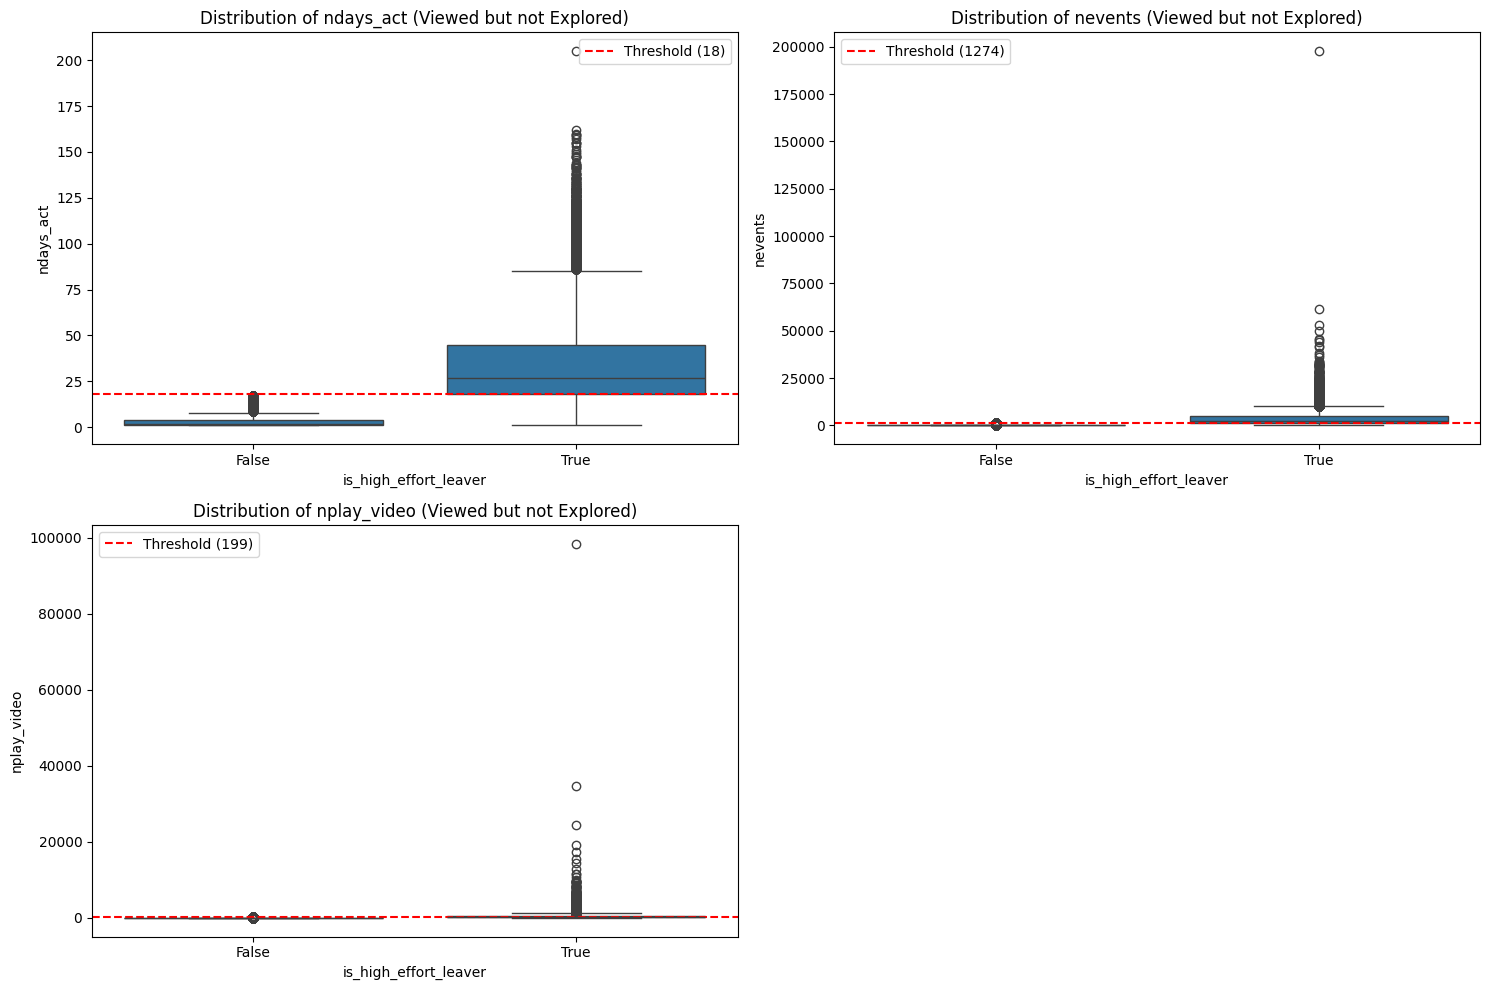

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

df = df.reset_index(drop=True)

# 임계값 설정
thresholds = {
    'ndays_act': 18,
    'nevents': 1274,
    'nplay_video': 199
}

# step 2 유저 그룹 분류 
# viewed에서 설정한 기준을 하나라도 넘긴 explored 임계점을 초과한 유저 추출
target_condition2 = (df['viewed'] == 1)
df['is_high_effort_leaver'] = target_condition2 & (
    (df['ndays_act'] >= thresholds['ndays_act']) |
    (df['nevents'] >= thresholds['nevents']) |
    (df['nplay_video'] >= thresholds['nplay_video'])
)

# 임계값 기준 분포 확인
features = ['ndays_act', 'nevents', 'nplay_video']
plt.figure(figsize=(15, 10))

for i, col in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='is_high_effort_leaver', y=col, data=df[target_condition2])
    plt.axhline(thresholds[col], color='red', linestyle='--', label=f'Threshold ({thresholds[col]})')
    plt.title(f'Distribution of {col} (Viewed but not Explored)')
    plt.legend()

plt.tight_layout()
plt.show()

In [92]:
# 유형 세분화
# Step 1. 진입 전 이탈
rr_step1 = ((df['registered'] == 1) & (df['viewed'] == 0)).sum()

# Step 2-1. explored 임계점 미달 유저
rr_step2_1 = ((df['viewed'] == 1) & (df['is_high_effort_leaver'] == False)).sum()

# Step 2-2. explored 임계점 초과 유저
rr_step2_2 = ((df['viewed'] == 1) & (df['is_high_effort_leaver'] == True)).sum()

print(f"진입 전 이탈 : {rr_step1:,}명")
print(f"explored 임계점 이하 유저 : {rr_step2_1:,}명")
print(f"explored 임계점 넘은 유저 : {rr_step2_2:,}명")

진입 전 이탈 : 208,632명
explored 임계점 이하 유저 : 282,004명
explored 임계점 넘은 유저 : 43,357명
